In [1]:
import pandas as pd
import sys
sys.path.append('../../')
from MEGA_utilities import data_col_standardize, data_remove_duplicate


# load data
Crick_H1N1 = pd.read_excel('../../../data/raw/data4model(Crick-H1N1).xlsx')
Crick_H3N2 = pd.read_excel('../../../data/raw/data4model(Crick-H3N2).xlsx')
origin_df = pd.concat([Crick_H1N1, Crick_H3N2]).reset_index(drop=True)

## DNA MEGA

In [2]:
## select required columns
AA_data_filt1 = origin_df[['serumName','virusName','serumHA', 'serumNA', 'virusHA', 'virusNA', 
                           'serumPassCat','virusPassCat', 'serumType', 'virusDate','HI_Dist']].copy()
## remove duplicated row and mean HI_Dist
AA_data_filt2 = AA_data_filt1.groupby(['serumHA', 'serumNA', 'virusHA', 'virusNA', 'serumPassCat', 'virusPassCat']) \
        .agg({'serumName': 'first', 'virusName': 'first', 'serumType': 'first', 'virusDate': 'first', 'HI_Dist': 'mean'}) \
        .reset_index()[['serumName', 'virusName', 'serumHA', 'serumNA', 'virusHA', 'virusNA',
                        'serumPassCat', 'virusPassCat', 'serumType', 'virusDate', 'HI_Dist']]
## remove PassCat = 'BOTH'
AA_data_filt3 = AA_data_filt2[(AA_data_filt2['serumPassCat'] != 'BOTH') &
                              (AA_data_filt2['virusPassCat'] != 'BOTH')].reset_index(drop=True)
## replace PassCat to special token
AA_data_filt4 = AA_data_filt3.replace({'serumPassCat': {'EGG': '<EGG>', 'CELL': '<CELL>'},
                                       'virusPassCat': {'EGG': '<EGG>', 'CELL': '<CELL>'}})

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

class AADataset(Dataset):
    def __init__(self, DataFrame):
        self.sequence = (DataFrame['serumHA'] + '<eos>' + DataFrame['serumNA'] + '<eos>' + DataFrame['virusHA'] + '<eos>' + DataFrame['virusNA'] + \
                         '<eos>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat']).tolist()
        self.labels = torch.tensor(DataFrame['HI_Dist'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequence[idx], self.labels[idx]

In [4]:
from sklearn.model_selection import train_test_split
from utilities import assign_season

train_df, test_df = train_test_split(AA_data_filt4, test_size=0.1, random_state=42)

## select contact sequences
test_filt1 = test_df.copy()
test_filt1 = test_filt1[(test_filt1['serumHA'].str.len() == 566) &
                        (test_filt1['serumNA'].str.len() == 469) &
                        (test_filt1['virusHA'].str.len() == 566) &
                        (test_filt1['virusNA'].str.len() == 469)]
## select H3N2
test_filt2 = test_filt1[test_filt1['serumType'] == 'H3N2']

test_data_final = test_filt2
test_dataset = AADataset(test_data_final)
test_loader = DataLoader(test_dataset, batch_size=80, shuffle=False)

In [5]:
from bio_tokenizer import BioTokenizer
from transformers import MegaConfig, MegaForSequenceClassification
from MEGA_utilities import count_parameters
from torch.optim import AdamW
from transformers import get_scheduler
import torch

# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')

# update the num_vocab and num_label
device = torch.device("cuda:1")
model = torch.load('../../../trained_model/1.2_HANA_model/2025-06-21_12-17-39.pth', weights_only=False, map_location=device)
print("Number of parameters: %e"%count_parameters(model))

Number of parameters: 1.135435e+06


In [6]:
from tqdm import tqdm
from utilities import print_exams
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
attentions_ls = []
progress_bar = tqdm(test_loader, desc="Evaluating")

model.eval()
for batch_seq, batch_label in test_loader:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)
    with torch.no_grad():
        outputs = model(**batch_input, labels=batch_label, output_attentions=True)
    logits = outputs.logits
    loss = outputs.loss

    attentions = [att.to('cpu') for att in outputs.attentions]
    attentions_ls.append(attentions)

    logits_ls.append(logits)
    loss_ls_valid.append(loss.item())
    prediction_ls += logits.tolist()
    prediction_ls_final = []
    for sublist in prediction_ls:
        for element in sublist:
            prediction_ls_final.append(element)
    reference_ls += batch_label.tolist()
    progress_bar.update(1)

print_exams(prediction_ls_final, reference_ls)
valid_MAE = mean_absolute_error(reference_ls, prediction_ls_final)
valid_mse = mean_squared_error(reference_ls, prediction_ls_final)
valid_pearson = pearsonr(reference_ls, prediction_ls_final).statistic
valid_spearman = spearmanr(reference_ls, prediction_ls_final).statistic

Evaluating: 100%|██████████| 43/43 [03:49<00:00,  4.54s/it]

MAE:  0.6844579514628222
MSE:  0.8216006966155962
pearson correlation:  PearsonRResult(statistic=0.8574656211328858, pvalue=0.0)
spearman correlation:  SignificanceResult(statistic=0.85882092460742, pvalue=0.0)


In [7]:
first_layer_attentions = []
second_layer_attentions = []
third_layer_attentions = []
fourth_layer_attentions = []
fifth_layer_attentions = []

for i in range(len(attentions_ls)):
    batch = attentions_ls[i]
    first_layer_attentions.extend(list(torch.unbind(batch[0].squeeze(1), dim=0)))
    second_layer_attentions.extend(list(torch.unbind(batch[1].squeeze(1), dim=0)))
    third_layer_attentions.extend(list(torch.unbind(batch[2].squeeze(1), dim=0)))
    fourth_layer_attentions.extend(list(torch.unbind(batch[3].squeeze(1), dim=0)))
    fifth_layer_attentions.extend(list(torch.unbind(batch[4].squeeze(1), dim=0)))

In [10]:
first_layer_sum = torch.zeros(2079, 2079)
second_layer_sum = torch.zeros(2079, 2079)  
third_layer_sum = torch.zeros(2079, 2079)
fourth_layer_sum = torch.zeros(2079, 2079)
fifth_layer_sum = torch.zeros(2079, 2079)

for tensor in first_layer_attentions:
    first_layer_sum += tensor
for tensor in second_layer_attentions:
    second_layer_sum += tensor
for tensor in third_layer_attentions:
    third_layer_sum += tensor
for tensor in fourth_layer_attentions:
    fourth_layer_sum += tensor
for tensor in fifth_layer_attentions:
    fifth_layer_sum += tensor

first_layer_mean = first_layer_sum / len(first_layer_attentions)
second_layer_mean = second_layer_sum / len(second_layer_attentions)
third_layer_mean = third_layer_sum / len(third_layer_attentions)
fourth_layer_mean = fourth_layer_sum / len(fourth_layer_attentions)
fifth_layer_mean = fifth_layer_sum / len(fifth_layer_attentions)


In [39]:
first_layer_mean.shape

torch.Size([2079, 2079])

In [40]:
torch.where(first_layer_mean>0.05)

(tensor([ 529,  530, 1330, 1565, 1566, 1567, 1680, 1682, 1878, 1880, 1881, 1889,
         1893, 1897, 1937]),
 tensor([ 398,  398, 1435, 1435, 1435, 1435, 1551, 1551, 1435, 1435, 1435, 1435,
         1435, 1435, 1481]))

In [37]:
torch.max(first_layer_mean)

tensor(0.0820)

In [51]:
torch.max(first_layer_mean, dim=0)

torch.return_types.max(
values=tensor([0.0026, 0.0053, 0.0039,  ..., 0.0220, 0.0263, 0.0222]),
indices=tensor([ 131,  130, 1798,  ..., 2029, 2029, 2029]))

In [57]:
def find_top_30_indices(lst):
    if len(lst) < 30:
        raise ValueError("列表中元素数量不足30个")
    # 获取列表中最大的30个数及其索引
    top_30_indices = sorted(range(len(lst)), key=lambda i: lst[i], reverse=True)[:30]
    return top_30_indices

sorted(find_top_30_indices(h1[:346].tolist()))

[13,
 14,
 15,
 16,
 17,
 26,
 79,
 81,
 86,
 110,
 121,
 168,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 210,
 211,
 264,
 265,
 266,
 267,
 268,
 333,
 334]

In [63]:
dd = first_layer_mean+second_layer_mean+third_layer_mean+fourth_layer_mean+fifth_layer_mean

In [67]:
dd.mean(0)

tensor([0.0115, 0.0115, 0.0107,  ..., 0.0505, 0.0487, 0.0505])

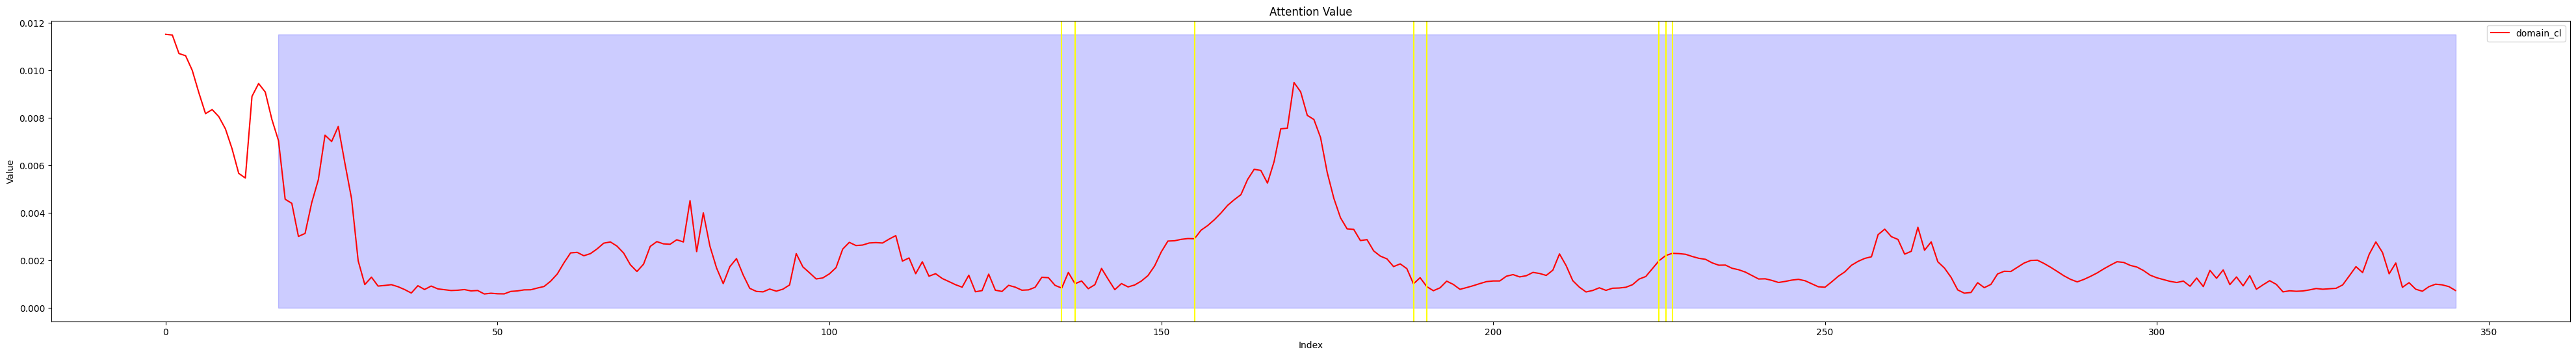

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

h1 = dd.mean(0)[0:346]
x = np.arange(len(h1))
window_size = 1

# 使用窗口平滑（移动平均法）
smoothed_data = np.convolve(h1, np.ones(window_size)/window_size, mode='valid')
plt.figure(figsize=(50, 6))

# 绘制原始数据和平滑后的数据
# plt.plot(range(window_size - 1, len(smoothed_data)), smoothed_data, label='domain_cl',  color='red')
plt.plot(range(len(h1)), h1, label='domain_cl',  color='red')
plt.fill_between(x, y1=max(h1),y2=0, where=((x >= 17) & (x <= 345)), color='blue', alpha=0.2) 
plt.fill_between(x, y1=max(h1),y2=0, where=((x >= 1054) & (x <= 1382)), color='blue', alpha=0.2) # + 1037

plt.axvline(x=135, color='yellow')
plt.axvline(x=137, color='yellow')
plt.axvline(x=155, color='yellow')
plt.axvline(x=188, color='yellow')
plt.axvline(x=190, color='yellow')
plt.axvline(x=225, color='yellow')
plt.axvline(x=226, color='yellow')
plt.axvline(x=227, color='yellow')

# 添加图例和标题
plt.legend()
plt.title('Attention Value')
plt.xlabel('Index')
plt.ylabel('Value')
plt.savefig('Site.png', bbox_inches='tight', dpi=300)

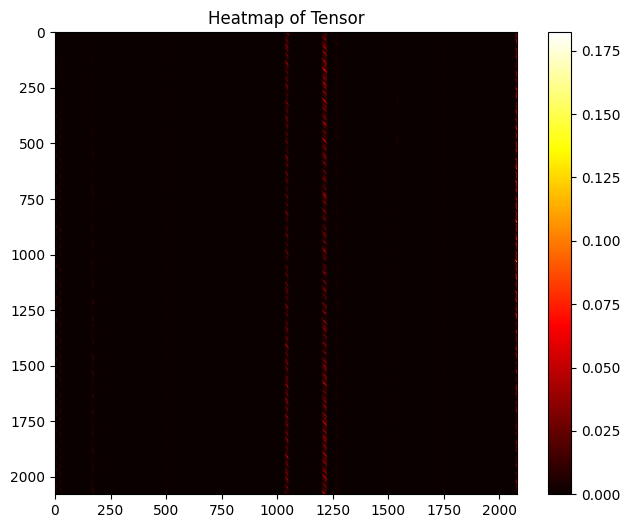

In [44]:
import torch
import matplotlib.pyplot as plt

# 创建一个形状为 [2079, 2079] 的张量
tensor = fourth_layer_mean# 示例数据

# 将张量转换为 NumPy 数组
tensor_np = tensor.numpy()

# 绘制热图
plt.figure(figsize=(8, 6))  # 设置图形大小
plt.imshow(tensor_np, cmap='hot', interpolation='nearest')  # 使用 viridis 色彩映射
plt.colorbar()  # 添加颜色条
plt.title("Heatmap of Tensor")  # 添加标题
plt.show()